<a href="https://colab.research.google.com/github/jx2260/PHYS-GA-2033-Prob-Set/blob/main/PS3_Phase_Retrieval_of_Nonlinear_Susceptibility_Tensors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Abstract:**

Rotational Anisotropy Second Harmonic Generation (RA-SHG) is a highly sensitive optical technique used to probe crystallographic symmetry, but extracting the underlying nonlinear susceptibility tensor ($\chi^{(2)}$) from intensity patterns is a complex, ill-posed inverse problem. Traditional least-squares fitting methods are computationally expensive and vulnerable to phase-retrieval degeneracies introduced by experimental noise and azimuthal misalignment.

We aim to develop a physics-informed deep learning framework capable of robust, high-throughput phase retrieval of nonlinear susceptibility tensors directly from RA-SHG data.


**Methods:**

We construct a 1D-Convolutional Neural Network (1D-CNN) that processes periodic RA-SHG intensity profiles $I(\phi)$ utilizing circular padding. To enforce the Neumann Principle, the network applies a dynamic hard symmetry mask conditioned on a crystallographic point group prior (e.g., $D_{3h}$ or $C_s$). This mask mathematically forces forbidden tensor elements to absolute zero before computing the loss via a Masked Mean Squared Error function. The model is trained on a synthetic dataset of parallel-polarization intensity patterns generated via a forward physical model. To simulate real-world conditions, this data is injected with randomized crystal orientation shifts and varying degrees of Gaussian noise.

**Anticipated Results:**

We anticipate the physics-informed 1D-CNN will invert RA-SHG spectra with rapid training convergence, maintaining high reconstruction fidelity up to 15% signal-to-noise degradation. Furthermore, we expect the hard structural prior to guarantee that component-wise errors for forbidden tensor elements remain exactly zero, even under extreme 50% noise limits.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class SHGGenerator:
    """
    Simulates Rotational Anisotropy Second Harmonic Generation (RA-SHG).
    Assumes normal incidence, collecting parallel polarization (S-in/S-out or P-in/P-out equivalent in 2D).
    """
    def __init__(self, num_points=100):
        # Rotation angles from 0 to 360 degrees
        self.phi_deg = np.linspace(0, 360, num_points)
        self.phi_rad = np.radians(self.phi_deg)

        # Calculate the incident electric field in Voigt notation for normal incidence
        # E_voigt = [Ex^2, Ey^2, Ez^2, 2EyEz, 2ExEz, 2ExEy]
        # For incident beam linearly polarized at angle phi: Ex = cos(phi), Ey = sin(phi), Ez = 0
        self.E_voigt = np.array([
            np.cos(self.phi_rad)**2,           # E_1 = Ex^2
            np.sin(self.phi_rad)**2,           # E_2 = Ey^2
            np.zeros(num_points),              # E_3 = Ez^2
            np.zeros(num_points),              # E_4 = 2EyEz
            np.zeros(num_points),              # E_5 = 2ExEz
            2 * np.cos(self.phi_rad) * np.sin(self.phi_rad) # E_6 = 2ExEy
        ])

    def get_d_matrix(self, point_group, params):
        """
        Constructs the 3x6 nonlinear optical d-tensor based on crystal symmetry.
        Sparsity patterns are strictly enforced by the Point Group.
        """
        d = np.zeros((3, 6))

        if point_group == 'D3h':
            # Symmetry: -6m2 (e.g., monolayer MoS2, GaSe)
            # Independent elements: d22
            # Sparsity: d16 = -d22, d21 = -d22
            d22 = params.get('d22', 1.0)
            d[0, 5] = -d22
            d[1, 0] = -d22
            d[1, 1] = d22

        elif point_group == 'Cs':
            # Symmetry: m (mirror plane perpendicular to y-axis)
            # Independent elements: d11, d12, d26 (ignoring out-of-plane)
            # Sparsity: Highly anisotropic, allowing mixing of x and y fields
            d[0, 0] = params.get('d11', 1.0)
            d[0, 1] = params.get('d12', 0.5)
            d[1, 5] = params.get('d26', 0.8)

        else:
            raise ValueError(f"Point group {point_group} not implemented.")

        return d

    def generate_pattern(self, point_group, params, noise_level=0.05):
        """Calculates SHG intensity with simulated experimental noise."""
        d_matrix = self.get_d_matrix(point_group, params)

        # P_i = sum_j (d_ij * E_j)
        P_induced = d_matrix @ self.E_voigt

        # Calculate Parallel Polarization (Analyzer rotates with Polarizer)
        # P_parallel = Px*cos(phi) + Py*sin(phi)
        P_parallel = P_induced[0] * np.cos(self.phi_rad) + P_induced[1] * np.sin(self.phi_rad)

        # I = |P|^2
        intensity = P_parallel**2

        # Add experimental constraints: normalize and add noise
        max_val = np.max(intensity)
        if max_val > 0:
            intensity = intensity / max_val

        # Add Gaussian noise (simulating PMT/detector noise)
        noise = np.random.normal(0, noise_level, size=intensity.shape)
        intensity = np.clip(intensity + noise, 0, None) # Intensity cannot be negative

        return intensity

In [ ]:
  def visualize_groups(self):
        """Generates a polar plot comparing the 2 symmetry groups."""
        groups = ['D3h', 'Cs']
        # Arbitrary physical parameters for demonstration
        params_list = [
            {'d22': 1.0},
            {'d11': 1.0, 'd12': 0.2, 'd26': 0.5}
        ]

        fig, axs = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(12, 6))
        axs = axs.flatten()

        for ax, group, params in zip(axs, groups, params_list):
            intensity = self.generate_pattern(group, params, noise_level=0.03)

            ax.plot(self.phi_rad, intensity, color='darkred', linewidth=2)
            ax.fill(self.phi_rad, intensity, color='red', alpha=0.2)

            # Format tensor values for the title
            tensor_str = ", ".join([f"{k}={v}" for k, v in params.items()])
            ax.set_title(f'Point Group: {group}\nTensor: [{tensor_str}]', va='bottom', pad=20)
            ax.set_rticks([]) # Hide radial ticks for cleaner look

        plt.tight_layout()
        plt.show()

In [ ]:
def create_dataset(self, samples_per_group=1000, filename='shg_synthetic_data.csv'):
        """Generates a large synthetic dataset and exports to CSV."""
        data = []
        groups = ['D3h', 'Cs']

        for group in groups:
            for _ in range(samples_per_group):
                # Randomize tensor elements between -1.0 and 1.0
                params = {
                    'd11': np.random.uniform(-1, 1),
                    'd22': np.random.uniform(-1, 1),
                    'd12': np.random.uniform(-1, 1),
                    'd26': np.random.uniform(-1, 1)
                }

                # Randomize noise between 1% and 10%
                noise = np.random.uniform(0.01, 0.1)

                intensity = self.generate_pattern(group, params, noise_level=noise)

                # Store data row
                row = {'point_group': group}
                # Store the labels (target d-tensor values)
                for key in ['d11', 'd22', 'd12', 'd26']:
                    row[key] = params[key] if key in params else 0.0
                # Store the features (intensity at each angle)
                for i, val in enumerate(intensity):
                    row[f'I_{i}'] = val

                data.append(row)

        df = pd.DataFrame(data)
        df.to_csv(filename, index=False)
        print(f"Dataset with {len(df)} samples saved to {filename}")

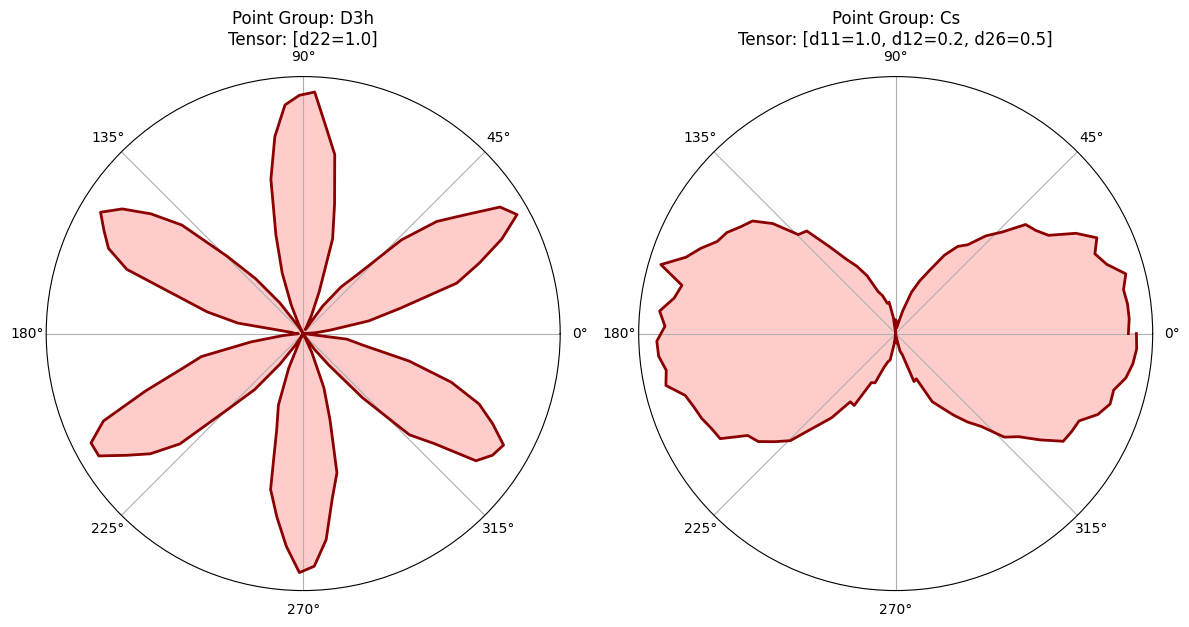

Dataset with 20000 samples saved to shg_synthetic_data.csv


In [ ]:
# Attach the method to the SHGGenerator class
SHGGenerator.create_dataset = create_dataset

if __name__ == "__main__":
    generator = SHGGenerator(num_points=100)

    generator.visualize_groups()

    generator.create_dataset(samples_per_group=10000)
